Arabic POS Tagging using BiLSTM

This project builds an Arabic Part-of-Speech (POS) tagging system using a BiLSTM deep learning model to assign grammatical labels (NOUN, VERB, ADJ, etc.) to each word in a sentence.

It uses an Arabic dataset in CoNLL-U format, which is preprocessed through tokenization, padding, and label encoding. The model architecture is:

Embedding → BiLSTM → TimeDistributed Dense → Softmax

The BiLSTM captures context from both directions, improving tagging accuracy.

The system achieved strong performance in terms of accuracy and F1-score, evaluated using classification reports and confusion matrices, with some difficulty on rare tags like PROPN and X.

A Streamlit app was developed to allow real-time POS tagging for user-input Arabic sentences.

Overall, the project demonstrates a full NLP pipeline from preprocessing and modeling to evaluation and deployment.

# `01` Import Libraries

In [39]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# `02` load data and preprossing 

In [40]:
def read_conllu(file_path):
    sentences, labels = [], []
    sentence, label = [], []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line == "":
                if sentence:
                    sentences.append(sentence)
                    labels.append(label)
                    sentence, label = [], []
                continue

            if line.startswith("#"):
                continue

            parts = line.split("\t")

            if len(parts) > 3:
                token = parts[1]
                pos_tag = parts[3]

                sentence.append(token)
                label.append(pos_tag)

    return sentences, labels

In [41]:
with open("Arabic_POS .conllu", "r", encoding="utf-8") as f:
    for i in range(10):
        print(f.readline())

# newdoc id = afp.20000715.0075

# newpar id = afp.20000715.0075:p1

# sent_id = afp.20000715.0075:p1u1

# text = برلين ترفض حصول شركة اميركية على رخصة تصنيع دبابة "ليوبارد" الالمانية

# orig_file_sentence AFP_ARB_20000715.0075#1

1	برلين	بَرلِين	X	X---------	Foreign=Yes	2	nsubj	2:nsubj	Vform=بَرلِين|Gloss=Berlin|Root=barlIn|Translit=barlīn|LTranslit=barlīn

2	ترفض	رَفَض	VERB	VIIA-3FS--	Aspect=Imp|Gender=Fem|Mood=Ind|Number=Sing|Person=3|VerbForm=Fin|Voice=Act	0	root	0:root	Vform=تَرفُضُ|Gloss=reject,refuse|Root=r f .d|Translit=tarfuḍu|LTranslit=rafaḍ

3	حصول	حُصُول	NOUN	N------S4R	Case=Acc|Definite=Cons|Number=Sing	2	obj	2:obj	Vform=حُصُولَ|Gloss=acquisition,obtaining,occurrence,happening|Root=.h .s l|Translit=ḥuṣūla|LTranslit=ḥuṣūl

4	شركة	شَرِكَة	NOUN	N------S2I	Case=Gen|Definite=Ind|Number=Sing	3	nmod	3:nmod:gen	Vform=شَرِكَةٍ|Gloss=company,corporation|Root=^s r k|Translit=šarikatin|LTranslit=šarikat

5	اميركية	أَمِيرِكِيّ	ADJ	A-----FS2I	Case=Gen|Definite=Ind|Gender=Fem|Number=Sing

In [42]:
def clean_tokens(sentence):
    return [re.sub(r"\s+", "", tok.strip()) for tok in sentence]

def clean_tags(tags):
    return [tag if tag != "_" else "O" for tag in tags]

In [43]:
sentences, labels = read_conllu("Arabic_POS .conllu")

sentences = [clean_tokens(s) for s in sentences]
labels = [clean_tags(l) for l in labels]

In [44]:
print(sentences[0])
print(labels[0])

['برلين', 'ترفض', 'حصول', 'شركة', 'اميركية', 'على', 'رخصة', 'تصنيع', 'دبابة', '"', 'ليوبارد', '"', 'الالمانية']
['X', 'VERB', 'NOUN', 'NOUN', 'ADJ', 'ADP', 'NOUN', 'NOUN', 'NOUN', 'PUNCT', 'X', 'PUNCT', 'ADJ']


In [45]:
for word, tag in zip(sentences[0], labels[0]):
    print(word, " --> ", tag)

برلين  -->  X
ترفض  -->  VERB
حصول  -->  NOUN
شركة  -->  NOUN
اميركية  -->  ADJ
على  -->  ADP
رخصة  -->  NOUN
تصنيع  -->  NOUN
دبابة  -->  NOUN
"  -->  PUNCT
ليوبارد  -->  X
"  -->  PUNCT
الالمانية  -->  ADJ


| Word          | Tag   | Meaning                          |
| ------------- | ----- | -------------------------------- |
| Berlin        | X     | Proper noun / unclassified token |
| rejects       | VERB  | Verb                             |
| obtaining     | NOUN  | Noun                             |
| company       | NOUN  | Noun                             |
| American      | ADJ   | Adjective                        |
| on            | ADP   | Adposition / Preposition         |
| license       | NOUN  | Noun                             |
| manufacturing | NOUN  | Noun                             |
| tank          | NOUN  | Noun                             |
| "             | PUNCT | Punctuation mark                 |
| Leopard       | X     | Proper noun / named entity       |
| "             | PUNCT | Punctuation mark                 |
| German        | ADJ   | Adjective                        |


  # POS Tags توزيع 

In [46]:
from collections import Counter

all_tags = [tag for sentence in labels for tag in sentence]
tag_counts = Counter(all_tags)

print(sorted(tag_counts.items(), key=lambda x: x[1], reverse=True))

[('NOUN', 74546), ('ADP', 33617), ('O', 30485), ('ADJ', 23498), ('PUNCT', 17511), ('VERB', 16807), ('CCONJ', 15791), ('X', 13747), ('PRON', 8533), ('NUM', 6010), ('DET', 4648), ('SCONJ', 4380), ('PART', 1709), ('AUX', 1699), ('ADV', 880), ('SYM', 329), ('PROPN', 187), ('INTJ', 7)]


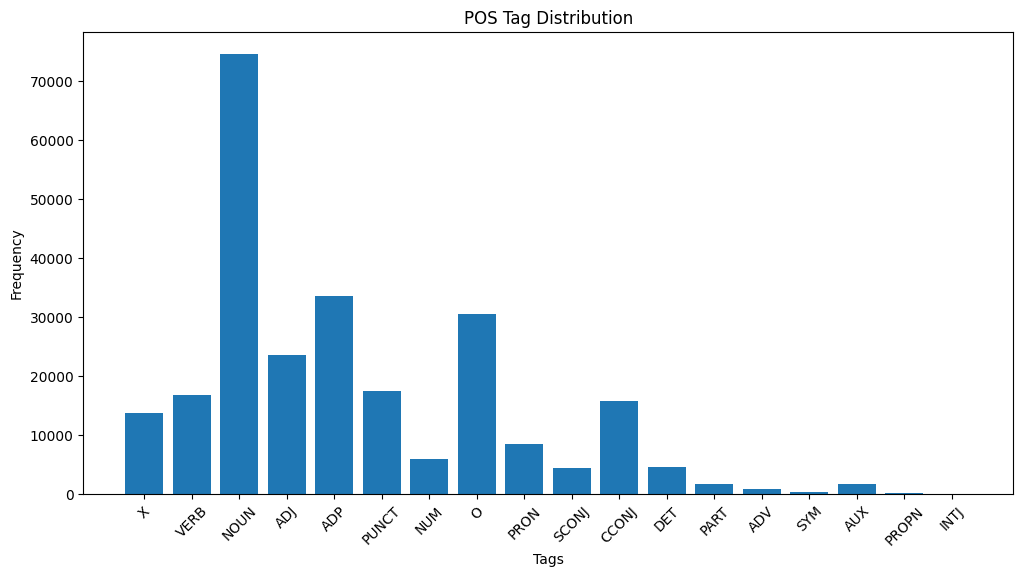

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(tag_counts.keys(), tag_counts.values())
plt.title("POS Tag Distribution")
plt.xlabel("Tags")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    sentences, labels, test_size=0.2, random_state=42
)

# Tokenizer

In [49]:
word_tokenizer = Tokenizer(oov_token="<OOV>")
word_tokenizer.fit_on_texts(X_train)

X_train_seq = word_tokenizer.texts_to_sequences(X_train)
X_test_seq  = word_tokenizer.texts_to_sequences(X_test)

tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts(y_train)

y_train_seq = tag_tokenizer.texts_to_sequences(y_train)
y_test_seq  = tag_tokenizer.texts_to_sequences(y_test)

 padding 

In [50]:
lengths = [len(x) for x in X_train_seq]
print(f"Max sentence length: {max(lengths)}")
print("95th percentile:", np.percentile(lengths, 95))
print("90th percentile:", np.percentile(lengths, 90))

Max sentence length: 478
95th percentile: 98.0
90th percentile: 78.0


In [51]:
MAX_LEN = 100

X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test  = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

y_train = pad_sequences(y_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
y_test  = pad_sequences(y_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

 reshape labels

In [52]:
y_train = np.array(y_train).reshape(-1, MAX_LEN, 1)
y_test  = np.array(y_test).reshape(-1, MAX_LEN, 1)

vocab sizes

In [53]:
vocab_size = len(word_tokenizer.word_index) + 1
num_tags = len(tag_tokenizer.word_index) + 1

# `03` Model (BiLSTM)


In [54]:
input_layer = Input(shape=(MAX_LEN,))

x = Embedding(vocab_size, 128, mask_zero=True)(input_layer)

x = Bidirectional(
    LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)
)(x)

output = TimeDistributed(Dense(num_tags, activation="softmax"))(x)

model = Model(input_layer, output)

In [55]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [56]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    save_best_only=True,
    monitor="val_loss"
)

# training

In [57]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler, checkpoint]
)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.3177 - loss: 2.4396

152/152 ━━━━━━━━━━━━━━━━━━━━ 35s 183ms/step - accuracy: 0.4323 - loss: 1.9849 - val_accuracy: 0.6424 - val_loss: 1.2182 - learning_rate: 5.0000e-04
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.6997 - loss: 0.9942

152/152 ━━━━━━━━━━━━━━━━━━━━ 27s 179ms/step - accuracy: 0.7562 - loss: 0.8183 - val_accuracy: 0.8597 - val_loss: 0.5097 - learning_rate: 5.0000e-04
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9006 - loss: 0.4064

152/152 ━━━━━━━━━━━━━━━━━━━━ 27s 176ms/step - accuracy: 0.9175 - loss: 0.3468 - val_accuracy: 0.9259 - val_loss: 0.2727 - learning_rate: 5.0000e-04
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9566 - loss: 0.2046

152/152 ━━━━━━━━━━━━━━━━━━━━ 27s 177ms/step - accuracy: 0.9601 - loss: 0.1849 - val_accuracy: 0.9432 - val_loss: 0.2050 - learning_rate: 5.0000e-04
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9713 - loss: 0.1282

152/152 ━━━━━━━━━━━━━━━━━━━━ 27s 178ms/step - accuracy: 0.9718 - loss: 0.1223 - val_accuracy: 0.9462 - val_loss: 0.1829 - learning_rate: 5.0000e-04
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.9769 - loss: 0.0956

152/152 ━━━━━━━━━━━━━━━━━━━━ 35s 231ms/step - accuracy: 0.9763 - loss: 0.0938 - val_accuracy: 0.9474 - val_loss: 0.1743 - learning_rate: 5.0000e-04
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9797 - loss: 0.0774

152/152 ━━━━━━━━━━━━━━━━━━━━ 38s 251ms/step - accuracy: 0.9792 - loss: 0.0767 - val_accuracy: 0.9490 - val_loss: 0.1682 - learning_rate: 5.0000e-04
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9817 - loss: 0.0678

152/152 ━━━━━━━━━━━━━━━━━━━━ 39s 255ms/step - accuracy: 0.9819 - loss: 0.0650 - val_accuracy: 0.9494 - val_loss: 0.1673 - learning_rate: 5.0000e-04
Epoch 9/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 29s 188ms/step - accuracy: 0.9838 - loss: 0.0563 - val_accuracy: 0.9491 - val_loss: 0.1692 - learning_rate: 5.0000e-04
Epoch 10/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 28s 184ms/step - accuracy: 0.9862 - loss: 0.0485 - val_accuracy: 0.9496 - val_loss: 0.1696 - learning_rate: 2.5000e-04


In [58]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=-1)
y_true = np.squeeze(y_test)

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step


# model evaluation

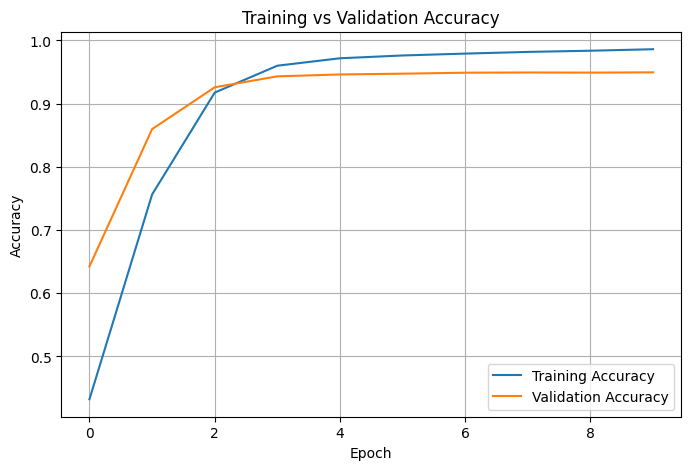

In [59]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [60]:
from sklearn.metrics import classification_report

true_tags = []
pred_tags = []

for t_seq, p_seq in zip(y_true, y_pred):
    for t, p in zip(t_seq, p_seq):
        if t != 0:
            true_tags.append(tag_tokenizer.index_word.get(t, "O"))
            pred_tags.append(tag_tokenizer.index_word.get(p, "O"))

print(classification_report(true_tags, pred_tags, zero_division=0))

              precision    recall  f1-score   support

         adj       0.92      0.91      0.91      4578
         adp       0.99      1.00      0.99      6432
         adv       0.98      0.85      0.91       178
         aux       0.86      0.86      0.86       342
       cconj       1.00      0.99      0.99      2967
         det       0.94      0.96      0.95       844
        noun       0.93      0.96      0.94     14296
         num       0.98      0.91      0.95      1266
           o       0.99      1.00      1.00      5844
        part       0.95      0.78      0.85       277
        pron       0.99      0.99      0.99      1595
       propn       1.00      0.56      0.72        43
       punct       1.00      1.00      1.00      3283
       sconj       0.97      1.00      0.98       861
         sym       1.00      0.89      0.94        56
        verb       0.95      0.87      0.91      3157
           x       0.77      0.77      0.77      2779

    accuracy              

In [61]:
labels = sorted(list(set(true_tags + pred_tags)))

cm = confusion_matrix(true_tags, pred_tags, labels=labels)

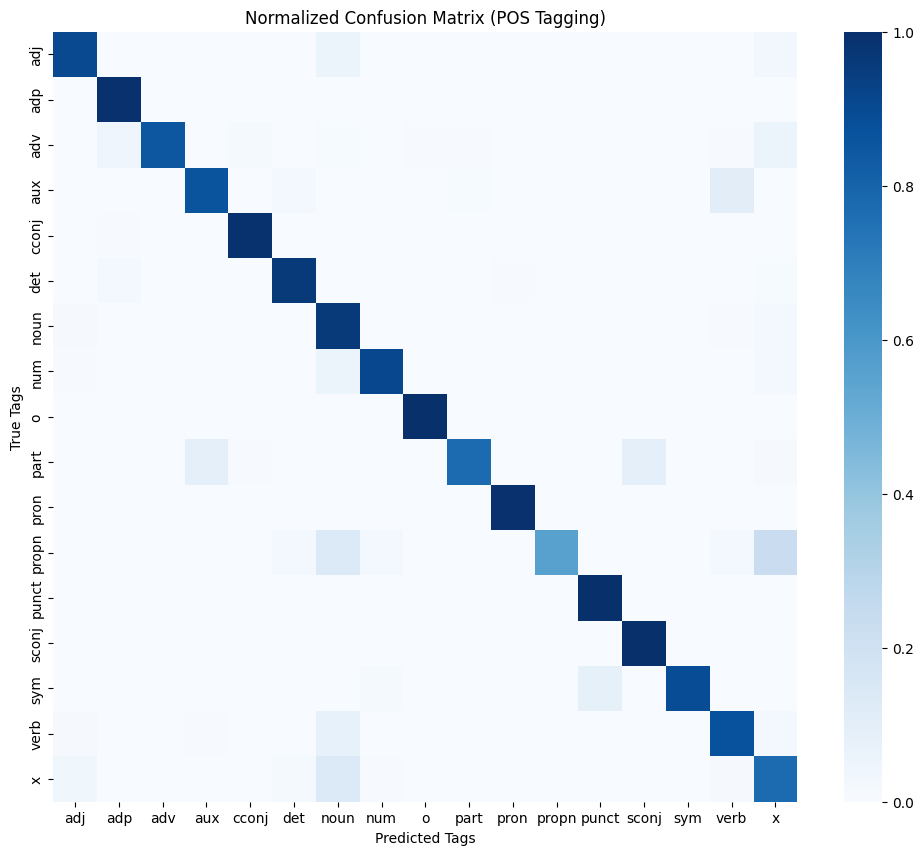

In [62]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_norm,
    annot=False,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Tags")
plt.ylabel("True Tags")
plt.title("Normalized Confusion Matrix (POS Tagging)")
plt.show()

Insights:

The model shows strong performance overall, with most predictions concentrated on the diagonal, indicating high correct classification rates across POS tags.
There is minor confusion between similar grammatical categories such as noun ↔ adj and noun ↔ x, which is expected in Arabic due to contextual overlap.
The PROPN and X tags show relatively higher dispersion, likely due to limited training samples and out-of-vocabulary words.
Rare or ambiguous tags (e.g., adv, part) exhibit slightly lower consistency compared to frequent classes like noun, adp, punct.
Overall, the model demonstrates good generalization ability with errors mainly in linguistically similar or low-frequency classes, rather than random misclassification.

In [63]:
import pickle
import json

# =========================
# 1. Save Model
# =========================

# الأفضل بدل h5
model.save("pos_bilstm_model.keras")

print("Model saved successfully!")

# =========================
# 2. Save Word Tokenizer
# =========================

with open("word_tokenizer.pkl", "wb") as f:
    pickle.dump(word_tokenizer, f)

print("Word tokenizer saved!")

# =========================
# 3. Save Tag Tokenizer
# =========================

with open("tag_tokenizer.pkl", "wb") as f:
    pickle.dump(tag_tokenizer, f)

print("Tag tokenizer saved!")

# =========================
# 4. Save Config
# =========================

config = {
    "MAX_LEN": MAX_LEN,
    "vocab_size": vocab_size,
    "num_tags": num_tags
}

with open("config.json", "w", encoding="utf-8") as f:
    json.dump(config, f)

print("Config saved successfully!")

Model saved successfully!
Word tokenizer saved!
Tag tokenizer saved!
Config saved successfully!
